# Proyecto Final DataXperience — Análisis de Ofertas de Empleo en TI
## Módulo 1: Fundamentos y Preparación de Datos

**Programa:** Ingeniería de Sistemas

**Integrantes:**
- Alejandra Leguizamon
- Francy Atehortua
- Nicolas Becerra

**Fecha:** agosto de 2026

**Dataset:** Global IT Job Listings Dataset — Kaggle (autor: himelsarder)
https://www.kaggle.com/datasets/himelsarder/global-it-job-listings-dataset

## 1. Objetivo del Módulo 1

Seleccionar, explorar y preparar un conjunto de datos realista: identificar tipos de variables y problemas de calidad, y limpiar el dataset (nulos, duplicados, errores y codificaciones inadecuadas) sin alterar el original.

## 2. Justificación del dataset

Elegimos el **Global IT Job Listings Dataset** porque, como estudiantes de **Ingeniería de Sistemas**, el mercado laboral TI es directamente uno de nuestros campos profesionales. Analizar ofertas de empleo reales nos permite:

- Identificar qué **roles** tienen mayor demanda.
- Entender los **niveles de experiencia** que piden las empresas.
- Ver la **distribución geográfica** de las oportunidades.

Además:
- Combina datos de **texto** y **categóricos**, ideal para practicar la identificación de tipos de variables.
- Su tamaño (**2.500 filas**) es manejable: ni demasiado pequeño ni difícil de procesar.
- Proviene de una **fuente confiable** (Kaggle).

## 3. Estructura del dataset

| Variable | Descripción | Tipo |
|---|---|---|
| `Job Title` | Nombre del puesto | Texto |
| `Company Name` | Empresa que publica la oferta | Texto / categórica |
| `Location` | Ciudad(es) o país(es) de la oferta | Texto / categórica |
| `Experience (Years)` | Rango de experiencia requerido (ej. "3 - 8 Years") | Texto (rango) |

---

## 4. Exploración inicial de los datos

---


In [429]:
import pandas as pd
df = pd.read_csv("IT_jobs.csv")

In [430]:
df.shape

(2500, 4)

El dataset contiene **2.500 registros** y **4 variables**. Esta primera inspección nos permite conocer el tamaño y la estructura antes de empezar la limpieza.

In [431]:
df.head()

,Job Title,Company Name,Location,Experience (Years)
0,Abroad Requirement IT Manager,RECRUITMENT CANADA IMMIGRATION CANADA,"Australia, Canada",7 - 12 Years
1,"""IT Sales Executive"" , Business Development Ex...",Serviots technology Pvt Ltd,Ahmedabad,2 - 6 Years
2,Facilities Manager,Sameer namdep Kedari,"Bengaluru / Bangalore, Sibsagar, Bhagalpur, ...",4 - 9 Years
3,SAP Experienced Candidates,TORRENT POWER LIMITED,Ahmedabad,3 - 5 Years
4,Technician- Electrical Maintenance,Suman kumar,"Delhi, Gurgaon, Pune, Indore, Bhubaneshwar",5 - 10 Years


In [432]:
df.columns

Index(['Job Title', 'Company Name', 'Location', 'Experience (Years)'], dtype='object')

In [433]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Title           2500 non-null   object
 1   Company Name        2500 non-null   object
 2   Location            2394 non-null   object
 3   Experience (Years)  2500 non-null   object
dtypes: object(4)
memory usage: 78.3+ KB


In [434]:
df.isnull().sum()

,0
Job Title,0
Company Name,0
Location,106
Experience (Years),0


La variable **`Location` contiene 106 valores nulos**, aproximadamente el **4,24 %** del dataset. El resto de variables no tiene valores faltantes.


In [435]:
df.duplicated().sum()

np.int64(216)

In [436]:
df[df.duplicated()]

,Job Title,Company Name,Location,Experience (Years)
44,Abroad Requiremen - Software Testing - CAN...,RECRUITMENT CANADA IMMIGRATION CANADA,"Other Gulf/Middle East Location(s), Australia...",8 - 13 Years
61,IT Recruiter,SKYWALK VISA IMMIGRATION SERVICES LLP,NaN,2 - 7 Years
137,IT-PMO - J48513,SAMPOORNA CONSULTANTS PVT LTD,Mumbai,2 - 4 Years
146,IT project Internship,Sparks To Ideas,Ahmedabad,0 - 1 Years
196,HR Executive- Talent Acquisition | Ludhiana,LifeInsuranceJobs . in,Ludhiana,0 - 3 Years
...,...,...,...,...
2369,Hiring for C Developer for an IT Company in Gu...,TandA HR Solutions,Gurgaon,2 - 5 Years
2393,Opening for Web Developer in Mohali for an IT ...,TandA HR Solutions,Mohali,2 - 3 Years
2431,Looking forTelesalesexecutivesfor an IT compan...,TandA HR Solutions,Mohali,3 - 6 Years
2445,Onsite IT Support Technician ( m / f / d ),DXC Technologies,Germany,2 - 5 Years


In [437]:
df[df.duplicated(keep=False)].head(10)

,Job Title,Company Name,Location,Experience (Years)
7,QA | QC Engineer Job In CANADA,World wide Immigration Service Llp,Canada,3 - 8 Years
10,Software Engineer Job In GERMANY,ADAL IMMIGRATIONS LLP,Germany,3 - 8 Years
13,QA | QC Engineer Job In NEW ZEALAND,World wide Immigration Service Llp,New Zealand,3 - 8 Years
22,AWS Solution Architect Internship in Pune,Maxgen Technologies,"Pune, Amravati, Dhule, Sangli, Satara",0 - 1 Years
30,Mern Stack Internship in Ahmedabad,Maxgen Technologies,"Ahmedabad, Anand, Gandhinagar, Mehsana, Surat",0 - 1 Years
34,Data Science Internship in Ahmedabad,Maxgen Technologies,"Ahmedabad, Bhavnagar, Junagarh, Rajkot, Su...",0 - 1 Years
41,Abroad Requiremen - Software Testing - CAN...,RECRUITMENT CANADA IMMIGRATION CANADA,"Other Gulf/Middle East Location(s), Australia...",8 - 13 Years
44,Abroad Requiremen - Software Testing - CAN...,RECRUITMENT CANADA IMMIGRATION CANADA,"Other Gulf/Middle East Location(s), Australia...",8 - 13 Years
55,IT Recruiter,SKYWALK VISA IMMIGRATION SERVICES LLP,NaN,2 - 7 Years
61,IT Recruiter,SKYWALK VISA IMMIGRATION SERVICES LLP,NaN,2 - 7 Years


Se identificaron **216 registros duplicados** (filas con la misma información en todas las columnas que una fila anterior). Se investigan aquí y se tratarán en la etapa de limpieza.

### Valores únicos y distribuciones iniciales
---



In [438]:
df.nunique()

,0
Job Title,1897
Company Name,416
Location,494
Experience (Years),83


El dataset contiene **1.897 títulos de puesto únicos**, **416 empresas**, **494 ubicaciones** y **83 valores de experiencia** distintos. El alto número de títulos únicos refleja una gran diversidad de puestos relacionados con TI.

---

In [439]:
df["Job Title"].value_counts().head(10)

,count
Job Title,
IT Service Management Representative,86
IT Manager,66
Finance & Accounts manager,17
Java Developer,11
Data Science Internship in Pune,10
IT Project Manager,9
Systems Analyst 2-IT,9
IT Customer Service Representative,9
Data Science Internship in Ahmedabad,9


In [440]:
df["Location"].value_counts().head(10)

,count
Location,
Bengaluru / Bangalore,287
Mohali,158
Mumbai,126
Pune,112
Hyderabad/Secunderabad,86
Chennai,62
Ahmedabad,61
Gurgaon,61
Germany,56


La distribución de ubicaciones muestra que **Bengaluru / Bangalore** concentra el mayor número de ofertas (**287**), seguida de **Mohali (158)**, **Mumbai (126)** y **Pune (112)**. La mayoría de las ubicaciones frecuentes están en India, aunque también aparece Alemania entre las primeras.

---

In [441]:
df["Experience (Years)"].value_counts().head(15)

,count
Experience (Years),
0 - 3 Years,222
0 - 1 Years,199
5 - 10 Years,183
3 - 8 Years,173
2 - 7 Years,143
2 - 5 Years,131
5 - 8 Years,92
3 - 6 Years,89
1 - 3 Years,78



La variable **`Experience (Years)` está expresada como rangos de texto**, no como números individuales. Los rangos más frecuentes son **0 - 3 años (222)**, **0 - 1 años (199)** y **5 - 10 años (183)**. Al estar guardada como texto, requiere transformación antes de cualquier análisis numérico.

---


Hay gran variedad de puestos de TI. **IT Service Management Representative** es el más frecuente (**86 ofertas**), seguido de **IT Manager (66)**. Después de los dos primeros, el número de ofertas por título baja bastante: muchos títulos aparecen pocas veces.

---

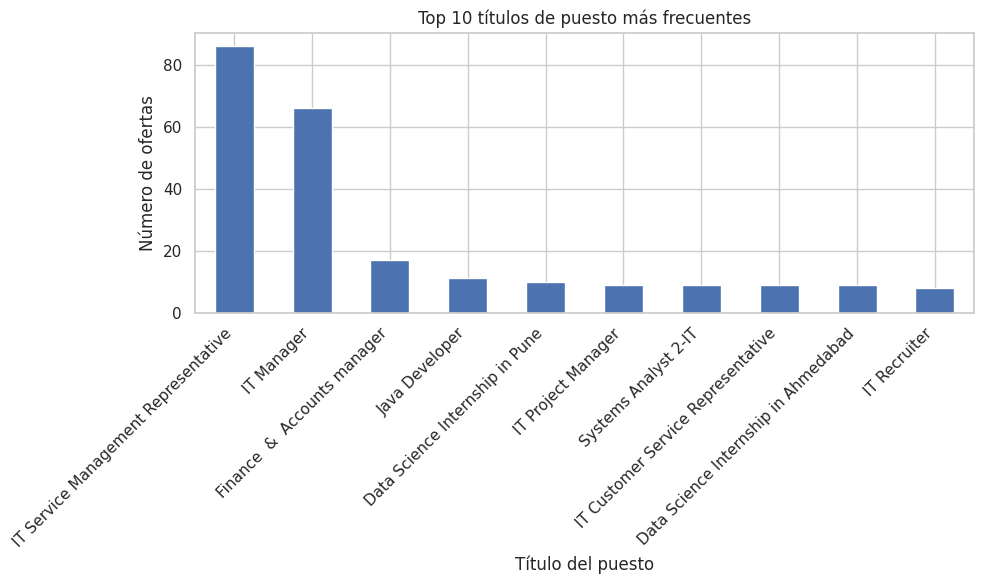

In [442]:
import matplotlib.pyplot as plt

top_jobs = df["Job Title"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_jobs.plot(kind="bar")
plt.title("Top 10 títulos de puesto más frecuentes")
plt.xlabel("Título del puesto")
plt.ylabel("Número de ofertas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

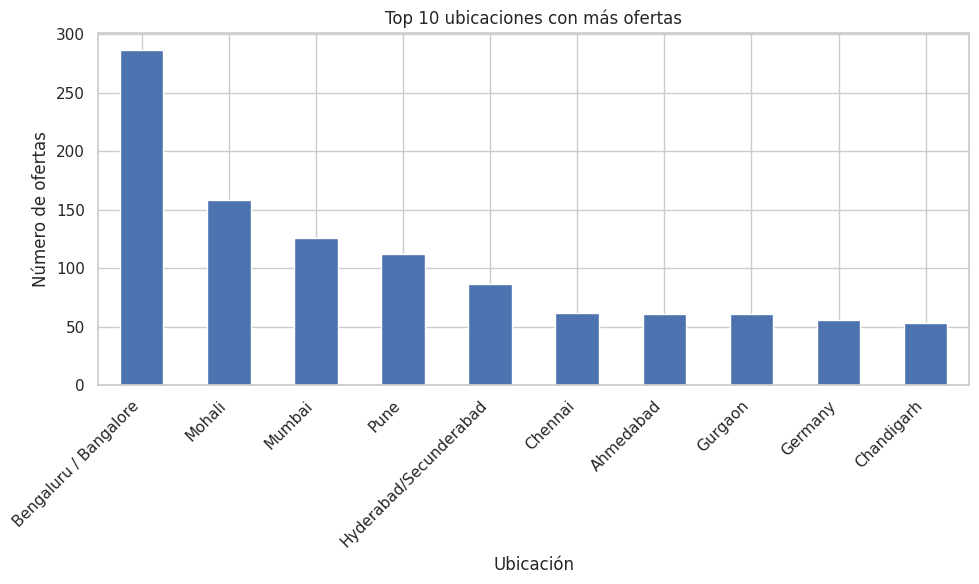

In [443]:
top_locations = df["Location"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_locations.plot(kind="bar")
plt.title("Top 10 ubicaciones con más ofertas")
plt.xlabel("Ubicación")
plt.ylabel("Número de ofertas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

La distribución geográfica muestra una fuerte concentración de ofertas en **India**. **Bengaluru / Bangalore** es la ubicación más frecuente (287), seguida de Mohali, Mumbai y Pune. Alemania también aparece dentro del top 10.

## 5. Limpieza y transformación de datos

Tras la exploración se detectaron varios problemas de calidad: registros duplicados, valores nulos en `Location` y rangos de experiencia guardados como texto. En esta etapa se corrigen **sin modificar el dataset original** (se trabaja sobre una copia, `df_clean`).

---


In [444]:
df_clean = df.copy()

In [445]:
df_clean.shape

(2500, 4)

In [446]:
df_clean.duplicated().sum()

np.int64(216)

In [447]:
df_clean = df_clean.drop_duplicates()

In [448]:
df_clean.shape

(2284, 4)

### 5.1 Duplicados

El dataset tenía **216 registros duplicados exactos**. Como repetían la misma información en todas las variables, se eliminaron para no contar la misma oferta varias veces. Tras eliminarlos quedan **2.284 registros**.

---

In [449]:
df_clean.isnull().sum()

,0
Job Title,0
Company Name,0
Location,104
Experience (Years),0


### 5.2 Valores nulos

Tras eliminar duplicados quedan **104 valores nulos** en `Location`. Como el resto de la información de esas filas sigue siendo útil, se reemplazan los nulos por **"Unknown"** en lugar de borrar las filas.

---

In [450]:
df_clean["Location"] = df_clean["Location"].fillna("Unknown")

In [451]:
df_clean.isnull().sum()

,0
Job Title,0
Company Name,0
Location,0
Experience (Years),0


### 5.3 Limpieza del texto de `Location`

Algunas filas listan varias ubicaciones separadas por comas y contienen el texto literal **`null`** dentro de la lista (ej. `"Canada,  Singapore,  null,  null,  null"`). Son **43 filas**. Se eliminan esos `null` sueltos y los espacios sobrantes, conservando las ubicaciones válidas.

---

In [452]:
def limpiar_ubicacion(valor):
    partes = [p.strip() for p in str(valor).split(",")]
    partes = [p for p in partes if p.lower() != "null" and p != ""]
    return ", ".join(partes) if partes else "Unknown"

In [453]:
# Cuántas filas tienen el token "null" antes de limpiar
print("Filas con 'null' antes:", df_clean["Location"].str.contains(r"\bnull\b", case=False).sum())

Filas con 'null' antes: 43


In [454]:
df_clean["Location"] = df_clean["Location"].apply(limpiar_ubicacion)

In [455]:
print("Filas con 'null' después:", df_clean["Location"].str.contains(r"\bnull\b", case=False).sum())

Filas con 'null' después: 0



Al normalizar el texto de `Location` (quitar los `null`), una oferta que antes se veía distinta quedó **idéntica** a otra ya existente (mismo puesto, empresa y experiencia). La limpieza destapó **1 duplicado oculto**, así que se vuelve a aplicar `drop_duplicates()`.

---

In [456]:
print("Duplicados tras normalizar Location:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Filas tras el segundo drop_duplicates:", df_clean.shape[0])

Duplicados tras normalizar Location: 1
Filas tras el segundo drop_duplicates: 2283


### 5.4 Transformación de la experiencia

`Experience (Years)` está guardada como rangos de texto ("0 - 3 Years", "5 - 10 Years"). Para poder analizarla numéricamente se extraen el valor **mínimo** y el **máximo** de cada rango en dos columnas nuevas, **conservando** la columna original para que la transformación sea trazable.

---

In [457]:
df_clean["Experience (Years)"].head(10)

,Experience (Years)
0,7 - 12 Years
1,2 - 6 Years
2,4 - 9 Years
3,3 - 5 Years
4,5 - 10 Years
5,1 - 4 Years
6,4 - 8 Years
7,3 - 8 Years
8,10 - 15 Years
9,2 - 7 Years


In [458]:
df_clean["Min Experience"] = (
    df_clean["Experience (Years)"]
    .str.extract(r"(\d+)\s*-")[0]
    .astype(int)
)

In [459]:
df_clean["Max Experience"] = (
    df_clean["Experience (Years)"]
    .str.extract(r"-\s*(\d+)")[0]
    .astype(int)
)

In [460]:
df_clean[[
    "Experience (Years)",
    "Min Experience",
    "Max Experience"
]].head(10)

,Experience (Years),Min Experience,Max Experience
0,7 - 12 Years,7,12
1,2 - 6 Years,2,6
2,4 - 9 Years,4,9
3,3 - 5 Years,3,5
4,5 - 10 Years,5,10
5,1 - 4 Years,1,4
6,4 - 8 Years,4,8
7,3 - 8 Years,3,8
8,10 - 15 Years,10,15
9,2 - 7 Years,2,7


Los rangos se separaron correctamente en dos variables numéricas: **`Min Experience`** y **`Max Experience`**. La columna original `Experience (Years)` se conserva.

---

In [461]:
df_clean[["Min Experience", "Max Experience"]].describe()

,Min Experience,Max Experience
count,"2,283.000","2,283.000"
mean,3.411,6.891
std,3.098,3.970
min,0.000,1.000
25%,1.000,4.000
50%,3.000,7.000
75%,5.000,9.000
max,20.000,25.000


En promedio, las ofertas piden entre **~3,4 y ~6,9 años** de experiencia. El mínimo va de 0 a 20 años y el máximo de 1 a 25 años, lo que confirma un rango amplio de seniority en el mercado.

---

In [462]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2283 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Title           2283 non-null   object
 1   Company Name        2283 non-null   object
 2   Location            2283 non-null   object
 3   Experience (Years)  2283 non-null   object
 4   Min Experience      2283 non-null   int64 
 5   Max Experience      2283 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 124.9+ KB


In [463]:
df_clean.isnull().sum()

,0
Job Title,0
Company Name,0
Location,0
Experience (Years),0
Min Experience,0
Max Experience,0


In [464]:
df_clean.shape

(2283, 6)

### 5.5 Estandarización de títulos de puesto

Se detectó un error de ortografía en `Job Title`: cuatro registros usan **"managment"** en vez de **"management"**. Se corrigen para mejorar la consistencia sin cambiar el significado del puesto.

---

In [465]:
df_clean[df_clean["Job Title"].str.contains("managment", case=False, na=False)]["Job Title"].value_counts()

,count
Job Title,
Finance & Accounts managment,4


In [466]:
df_clean["Job Title"] = df_clean["Job Title"].str.replace(
    "managment", "management", case=False, regex=False
)

In [467]:
df_clean[df_clean["Job Title"].str.contains("managment", case=False, na=False)]["Job Title"].value_counts()

,count
Job Title,


## 6. Validación final del dataset depurado

---

In [468]:
print("Duplicados:", df_clean.duplicated().sum())
print("Nulos totales:", df_clean.isnull().sum().sum())
print("Dimensiones:", df_clean.shape)

Duplicados: 0
Nulos totales: 0
Dimensiones: (2283, 6)


In [469]:
summary = {
    "Métrica": [
        "Número de registros",
        "Número de variables",
        "Registros duplicados",
        "Valores nulos en Location",
        "Variables numéricas de experiencia",
    ],
    "Antes de limpiar": [2500, 4, 216, 106, 0],
    "Después de limpiar": [
        df_clean.shape[0],
        df_clean.shape[1],
        int(df_clean.duplicated().sum()),
        int(df_clean["Location"].isnull().sum()),
        2,
    ],
}

pd.DataFrame(summary)

,Métrica,Antes de limpiar,Después de limpiar
0,Número de registros,2500,2283
1,Número de variables,4,6
2,Registros duplicados,216,0
3,Valores nulos en Location,106,0
4,Variables numéricas de experiencia,0,2


## 7. Conclusión del Módulo 1

El dataset depurado tiene **2.283 registros** y **6 variables**. Se eliminaron **216 duplicados exactos** y **1 duplicado adicional** que quedó al descubierto tras limpiar el texto de `Location`; se imputaron **104 ubicaciones faltantes** como "Unknown", se limpiaron **43 textos de `Location`** con el token `null`, se transformó `Experience (Years)` en las variables numéricas `Min Experience` y `Max Experience`, y se corrigieron **4 errores ortográficos** en los títulos. La validación final confirma **0 duplicados** y **0 valores nulos**. El dataset queda listo para el análisis del Módulo 2.

---

In [470]:
df_final = df_clean.copy()
df_final.to_csv("IT_jobs_clean.csv", index=False)
print("Guardado IT_jobs_clean.csv con", df_final.shape[0], "filas y", df_final.shape[1], "columnas")
df_final.head()

Guardado IT_jobs_clean.csv con 2283 filas y 6 columnas


,Job Title,Company Name,Location,Experience (Years),Min Experience,Max Experience
0,Abroad Requirement IT Manager,RECRUITMENT CANADA IMMIGRATION CANADA,"Australia, Canada",7 - 12 Years,7,12
1,"""IT Sales Executive"" , Business Development Ex...",Serviots technology Pvt Ltd,Ahmedabad,2 - 6 Years,2,6
2,Facilities Manager,Sameer namdep Kedari,"Bengaluru / Bangalore, Sibsagar, Bhagalpur, Mu...",4 - 9 Years,4,9
3,SAP Experienced Candidates,TORRENT POWER LIMITED,Ahmedabad,3 - 5 Years,3,5
4,Technician- Electrical Maintenance,Suman kumar,"Delhi, Gurgaon, Pune, Indore, Bhubaneshwar",5 - 10 Years,5,10


## Módulo 2: Análisis Estadístico

**Programa:** Ingeniería de Sistemas

**Fecha:** septiembre de 2026

**Punto de partida:** `IT_jobs_clean.csv` (dataset depurado en el Módulo 1 — 2.283 filas, 6 columnas).

---

## Objetivo del Módulo 2

Aplicar medidas estadísticas descriptivas para comprender el comportamiento de los datos.

En este notebook vamos a:
1. Calcular e interpretar **medidas de tendencia central** (media, mediana, moda).
2. Calcular e interpretar **medidas de posición** (cuartiles, deciles, percentiles).
3. Calcular e interpretar **medidas de dispersión** (rango, varianza, desviación estándar, coeficiente de variación).
4. Analizar la **forma de la distribución** (asimetría y curtosis).
5. **Comparar y contrastar** variables (ofertas locales vs. en el exterior; relación entre experiencia mínima y máxima).
6. Detectar **valores atípicos** con la regla del rango intercuartílico (IQR).
7. Mostrar el **escalado** de datos (normalización y estandarización).

In [471]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

In [472]:
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

In [473]:
df = pd.read_csv("IT_jobs_clean.csv")

In [474]:
print(df.shape)
df.head()

(2283, 6)


,Job Title,Company Name,Location,Experience (Years),Min Experience,Max Experience
0,Abroad Requirement IT Manager,RECRUITMENT CANADA IMMIGRATION CANADA,"Australia, Canada",7 - 12 Years,7,12
1,"""IT Sales Executive"" , Business Development Ex...",Serviots technology Pvt Ltd,Ahmedabad,2 - 6 Years,2,6
2,Facilities Manager,Sameer namdep Kedari,"Bengaluru / Bangalore, Sibsagar, Bhagalpur, Mu...",4 - 9 Years,4,9
3,SAP Experienced Candidates,TORRENT POWER LIMITED,Ahmedabad,3 - 5 Years,3,5
4,Technician- Electrical Maintenance,Suman kumar,"Delhi, Gurgaon, Pune, Indore, Bhubaneshwar",5 - 10 Years,5,10


In [475]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2283 entries, 0 to 2282
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Title           2283 non-null   object
 1   Company Name        2283 non-null   object
 2   Location            2283 non-null   object
 3   Experience (Years)  2283 non-null   object
 4   Min Experience      2283 non-null   int64 
 5   Max Experience      2283 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 107.1+ KB


## 1. Preparación de variables numéricas

El dataset tiene 6 columnas, pero solo **`Min Experience`** y **`Max Experience`** son numéricas. Para un análisis estadístico más rico creamos tres variables derivadas:

- **`Experiencia Media`** = punto medio del rango `(Min + Max) / 2`. Resume en un solo número la experiencia que pide cada oferta.
- **`Rango Experiencia`** = `Max - Min`. Mide qué tan amplio (flexible) es el rango pedido.
- **`Num Ubicaciones`** = cuántas ciudades/países lista la oferta.

---

In [476]:
df["Experiencia Media"] = (df["Min Experience"] + df["Max Experience"]) / 2

In [477]:
df["Rango Experiencia"] = df["Max Experience"] - df["Min Experience"]

In [478]:
df["Num Ubicaciones"]   = df["Location"].apply(
    lambda x: 1 if x == "Unknown" else len(x.split(", "))
)

In [479]:
numericas = ["Min Experience", "Max Experience", "Experiencia Media",
             "Rango Experiencia", "Num Ubicaciones"]
df[numericas].head()

,Min Experience,Max Experience,Experiencia Media,Rango Experiencia,Num Ubicaciones
0,7,12,9.50,5,2
1,2,6,4.00,4,1
2,4,9,6.50,5,5
3,3,5,4.00,2,1
4,5,10,7.50,5,5


In [480]:
df[numericas].describe().round(2)

,Min Experience,Max Experience,Experiencia Media,Rango Experiencia,Num Ubicaciones
count,"2,283.00","2,283.00","2,283.00","2,283.00","2,283.00"
mean,3.41,6.89,5.15,3.48,1.92
std,3.10,3.97,3.47,1.57,1.52
min,0.00,1.00,0.50,1.00,1.00
25%,1.00,4.00,2.50,2.00,1.00
50%,3.00,7.00,4.50,3.00,1.00
75%,5.00,9.00,7.00,5.00,2.00
max,20.00,25.00,22.50,10.00,5.00


La tabla `describe()` da una primera foto: en promedio las ofertas piden de **~3,4 a ~6,9 años** de experiencia, con un punto medio de **~5,2 años**. El rango pedido es de **~3,5 años** de amplitud media y la mayoría de ofertas se publican para **1 sola ubicación** (media 1,9). Los máximos (20–25 años, 5 ubicaciones) ya anticipan la presencia de valores atípicos.

---


## 2. Medidas de tendencia central

La **media** es el promedio; la **mediana** es el valor central (más robusta frente a valores extremos); la **moda** es el valor más frecuente. Compararlas nos dice si la distribución es simétrica o está sesgada.

---

In [481]:
tendencia = pd.DataFrame({
    "Media":   df[numericas].mean(),
    "Mediana": df[numericas].median(),
    "Moda":    df[numericas].mode().iloc[0],
}).round(2)
tendencia

,Media,Mediana,Moda
Min Experience,3.41,3.00,0.00
Max Experience,6.89,7.00,8.00
Experiencia Media,5.15,4.50,1.50
Rango Experiencia,3.48,3.00,5.00
Num Ubicaciones,1.92,1.00,1.00


**Interpretación:**
- En `Min Experience` la **media (3,41) > mediana (3,0) > moda (0)**. Cuando media > mediana > moda la distribución tiene **asimetría positiva**: muchas ofertas piden 0–1 años y unas pocas piden muchísimos, y esos casos altos empujan la media hacia arriba.
- En `Max Experience` media (6,89) y mediana (7,0) casi coinciden → distribución más equilibrada, con moda en 8 años.
- `Experiencia Media`: media 5,15 frente a mediana 4,5 → de nuevo asimetría positiva.
- `Num Ubicaciones`: moda y mediana valen 1 → la mayoría de ofertas son de una sola ciudad; la media 1,9 sube por las ofertas multi-ubicación.

---

In [482]:
for col in ["Job Title", "Company Name", "Location"]:
    top = df[col].value_counts()
    print(f"{col}: moda = {top.index[0]!r}  ({top.iloc[0]} ofertas, "
          f"{top.iloc[0]/len(df)*100:.1f}% del total)")

Job Title: moda = 'IT Manager'  (66 ofertas, 2.9% del total)
Company Name: moda = 'TandA HR Solutions'  (350 ofertas, 15.3% del total)
Location: moda = 'Bengaluru / Bangalore'  (256 ofertas, 11.2% del total)


**Interpretación (variables categóricas):**
- El puesto más frecuente es **IT Manager** (66 ofertas).
- La empresa que más publica es **TandA HR Solutions** con **350 ofertas (15,3 % de todo el dataset)**: una sola consultora de RR. HH. concentra buena parte de las publicaciones. Esto hay que tenerlo en cuenta para no sesgar conclusiones.
- La ubicación más frecuente es **Bengaluru / Bangalore** (256 ofertas), confirmando la fuerte concentración del mercado en India ya vista en el Módulo 1.

---

## 3. Medidas de posición: cuartiles, deciles y percentiles

Dividen los datos ordenados en partes iguales y nos dicen dónde cae un valor respecto al resto. Los calculamos sobre `Experiencia Media`.

---

In [483]:
exp = df["Experiencia Media"]

print("Cuartiles (Q1, Q2, Q3):", exp.quantile([0.25, 0.50, 0.75]).round(2).tolist())
print("Deciles (D1..D9):      ", exp.quantile(np.arange(0.1, 1.0, 0.1)).round(2).tolist())
print("Percentiles P90/P95/P99:", exp.quantile([0.90, 0.95, 0.99]).round(2).tolist())

Cuartiles (Q1, Q2, Q3): [2.5, 4.5, 7.0]
Deciles (D1..D9):       [1.5, 2.0, 3.0, 4.0, 4.5, 5.5, 6.5, 7.5, 10.0]
Percentiles P90/P95/P99: [10.0, 11.5, 17.5]


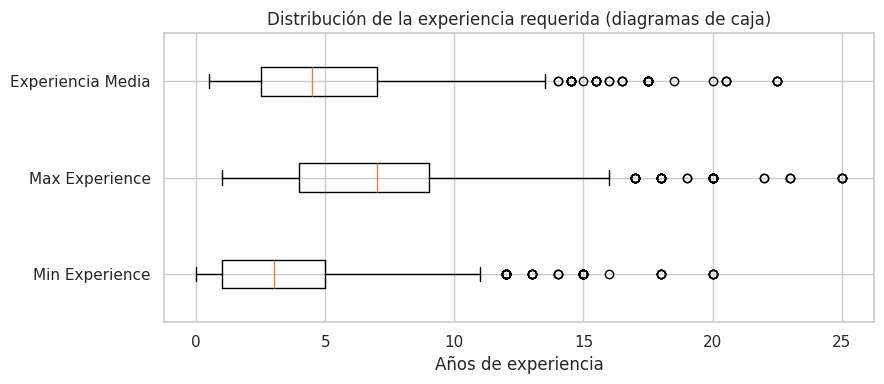

In [484]:
plt.figure(figsize=(9, 4))
plt.boxplot([df["Min Experience"], df["Max Experience"], df["Experiencia Media"]],
            tick_labels=["Min Experience", "Max Experience", "Experiencia Media"],
            vert=False)
plt.title("Distribución de la experiencia requerida (diagramas de caja)")
plt.xlabel("Años de experiencia")
plt.tight_layout()
plt.show()

### Nuestro gráfico, traducido a números

```
años →  0     5     10          15          20    25
        |-----|-----|-----------|-----------|-----|

Min Exp    [==|===]········  ·      ·       ·           caja 1–5, mediana 3
Max Exp       [===|====]········   ·    ·      ·  ·      caja 4–9, mediana 7
Exp Media  [=|=====]········  ·     ·      ·            caja 2,5–7, mediana 4,5

          ( los · son las ~50 ofertas de dirección: 18–25 años )
```

| Variable | Q1 (25 %) | Mediana | Q3 (75 %) | Caja = 50 % central | Fin del bigote | Valores atípicos |
|---|---|---|---|---|---|---|
| `Min Experience` | 1 año | 3 años | 5 años | 1 – 5 años | 11 años | 58 ofertas (2,5 %), hasta 20 años |
| `Max Experience` | 4 años | 7 años | 9 años | 4 – 9 años | 16,5 años | 48 ofertas (2,1 %), hasta 25 años |
| `Experiencia Media` | 2,5 años | 4,5 años | 7 años | 2,5 – 7 años | 13,8 años | 50 ofertas (2,2 %), hasta ~22 años |

**Qué significa para el mercado IT:**
- `Min Experience` es la caja más pequeña y pegada a la izquierda: el 50 % central de las ofertas pide entre **1 y 5 años** de experiencia mínima (típica: 3). La puerta de entrada al mercado es baja.
- `Max Experience` está más a la derecha (**4 a 9 años**, típica 7): las empresas ponen un techo de 7–9 años; buscan recorrido, no seniority extremo.
- `Experiencia Media`: la oferta típica apunta a un perfil **mid-level de ~4,5 años**.
- Las tres cajas tienen cola de puntos solo a la derecha → **asimetría positiva** (sesgo a la derecha), confirmada con números en la sección 5. Solo el 1 % de las ofertas pide más de 17,5 años (percentil 99).

---

## 4. Medidas de dispersión

- **Rango** = máximo − mínimo.
- **Varianza** = promedio de las diferencias al cuadrado respecto a la media.
- **Desviación estándar** = raíz de la varianza, en las mismas unidades que los datos.
- **Coeficiente de variación (CV)** = desviación estándar / media × 100. Permite comparar la variabilidad relativa entre variables con escalas distintas.

---

In [485]:
dispersion = pd.DataFrame({
    "Rango":    df[numericas].max() - df[numericas].min(),
    "Varianza": df[numericas].var(),
    "Desv. Estándar": df[numericas].std(),
    "CV (%)":   df[numericas].std() / df[numericas].mean() * 100,
}).round(2)
dispersion

,Rango,Varianza,Desv. Estándar,CV (%)
Min Experience,20.00,9.60,3.10,90.82
Max Experience,24.00,15.76,3.97,57.62
Experiencia Media,22.00,12.07,3.47,67.43
Rango Experiencia,9.00,2.47,1.57,45.12
Num Ubicaciones,4.00,2.30,1.52,78.92


**Interpretación:**
- `Min Experience` es la variable **más dispersa en términos relativos** (CV ≈ 91 %): las exigencias de experiencia mínima van desde 0 hasta 20 años.
- `Max Experience` tiene un CV de ≈ 58 %: menos disperso, porque casi ninguna oferta baja de 1 año en el tope del rango.
- `Rango Experiencia` es el **más homogéneo** (CV ≈ 45 %): la mayoría de las empresas define ventanas de experiencia parecidas (2 a 5 años de amplitud).
- Una desviación estándar de ~3,1 años en `Min Experience` frente a una media de 3,4 confirma que los datos están muy repartidos, no concentrados alrededor del promedio.

---

## 5. Forma de la distribución: asimetría y curtosis

- **Asimetría (skewness):** > 0 cola a la derecha; ≈ 0 simétrica; < 0 cola a la izquierda.
- **Curtosis (kurtosis):** > 0 pico alto y colas pesadas; ≈ 0 parecida a la normal.

---

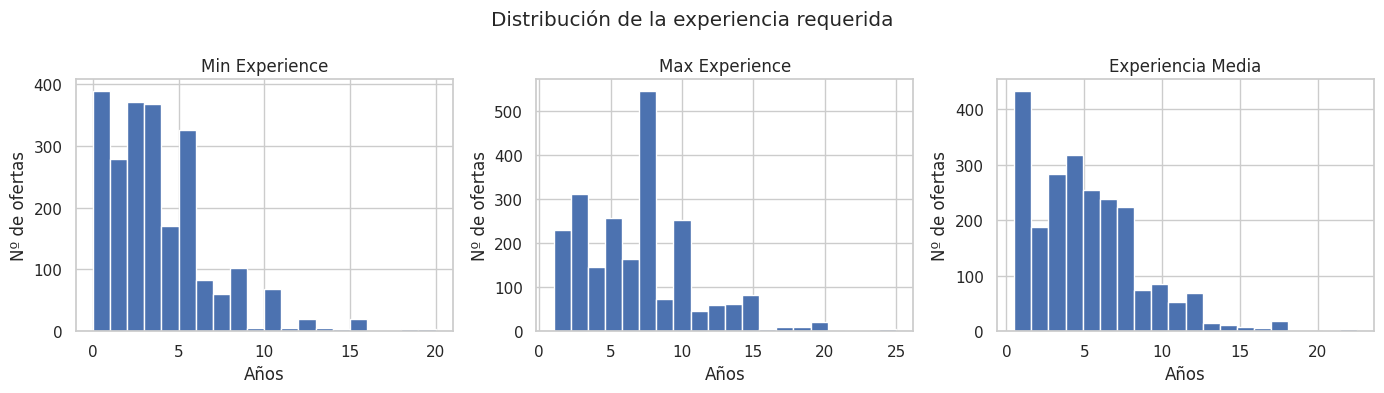

In [486]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Min Experience", "Max Experience", "Experiencia Media"]):
    ax.hist(df[col], bins=20, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Años")
    ax.set_ylabel("Nº de ofertas")
fig.suptitle("Distribución de la experiencia requerida")
plt.tight_layout()
plt.show()

In [487]:
forma = pd.DataFrame({
    "Asimetría (skew)": df[numericas].skew(),
    "Curtosis (kurt)":  df[numericas].kurt(),
}).round(2)
forma

,Asimetría (skew),Curtosis (kurt)
Min Experience,1.52,3.40
Max Experience,0.92,1.31
Experiencia Media,1.21,2.27
Rango Experiencia,0.50,1.21
Num Ubicaciones,1.29,-0.05


**Interpretación:**
- **Todas** las variables de experiencia tienen **asimetría positiva** (skew entre 0,9 y 1,5): hay una cola larga hacia la derecha formada por las ofertas muy senior.
- La curtosis de `Min Experience` (≈ 3,4) indica un pico pronunciado en los valores bajos (0–1 años) más colas pesadas.
- **Ninguna** de estas variables sigue una distribución normal. Esto es importante: si más adelante quisiéramos aplicar modelos que asumen normalidad, primero habría que transformar o escalar estas variables (sección 8).

---

## 6. Comparar y contrastar variables

### 6.1 Ofertas locales vs. ofertas en el exterior

Marcamos como "oferta en el exterior" toda publicación cuya ubicación menciona un país fuera de India (Australia, Canadá, Alemania, Nueva Zelanda, Singapur, EE. UU., etc.) o cuyo título incluye "abroad" / "job in".

---

In [488]:
paises_ext = ["Australia", "Canada", "Germany", "New Zealand", "Singapore",
              "USA", "United States", "UK", "United Kingdom", "Ireland",
              "Netherlands", "Dubai", "UAE", "Qatar", "Saudi"]
patron = "|".join(paises_ext)

In [489]:
df["Oferta Exterior"] = (
    df["Location"].str.contains(patron, case=False, na=False) |
    df["Job Title"].str.contains(r"abroad|job in", case=False, na=False)
)

In [490]:
print(df["Oferta Exterior"].value_counts())
print(f"\n{df['Oferta Exterior'].mean()*100:.1f}% de las ofertas son para el exterior")

Oferta Exterior
False    1933
True      350
Name: count, dtype: int64

15.3% de las ofertas son para el exterior


In [491]:
comparacion = df.groupby("Oferta Exterior")["Experiencia Media"].agg(
    ["count", "mean", "median", "std"]
).round(2)
comparacion

,count,mean,median,std
Oferta Exterior,,,,
False,1933,4.98,4.50,3.64
True,350,6.12,5.50,2.09


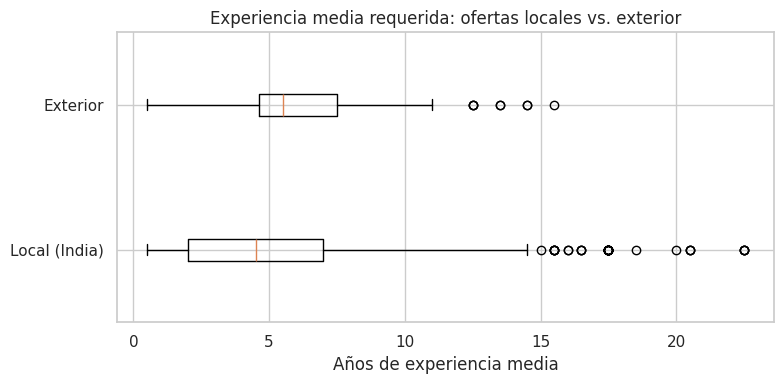

In [492]:
plt.figure(figsize=(8, 4))
datos = [df.loc[~df["Oferta Exterior"], "Experiencia Media"],
         df.loc[df["Oferta Exterior"],  "Experiencia Media"]]
plt.boxplot(datos, tick_labels=["Local (India)", "Exterior"], vert=False)
plt.title("Experiencia media requerida: ofertas locales vs. exterior")
plt.xlabel("Años de experiencia media")
plt.tight_layout()
plt.show()

**Interpretación:**
- El **15,3 %** de las ofertas son para el exterior.
- Piden **más experiencia**: media de **6,1 años** frente a **5,0** en las locales (mediana 5,5 vs. 4,5).
- Pero son **menos dispersas** (desv. estándar 2,1 vs. 3,6): las ofertas internacionales se concentran en perfiles de experiencia media-alta, mientras que el mercado local cubre desde practicantes hasta directivos.
- **Lectura profesional:** para aspirar a una oferta fuera de India conviene apuntar a un perfil de 5–8 años de experiencia; el mercado local tiene más espacio para perfiles junior.

---

Correlación Min Experience vs Max Experience: 0.931


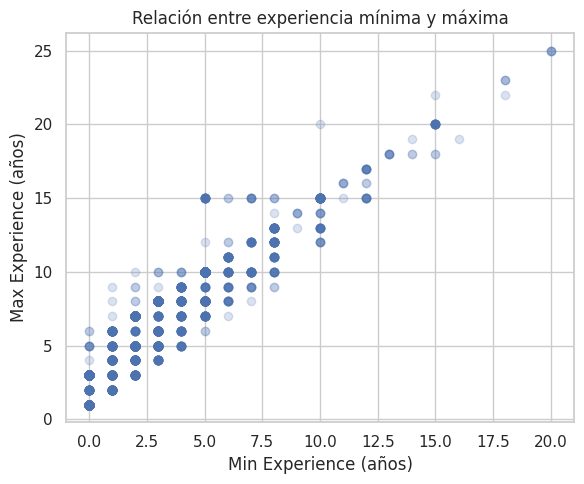

In [493]:
correlacion = df["Min Experience"].corr(df["Max Experience"])
print(f"Correlación Min Experience vs Max Experience: {correlacion:.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(df["Min Experience"], df["Max Experience"], alpha=0.2)
plt.xlabel("Min Experience (años)")
plt.ylabel("Max Experience (años)")
plt.title("Relación entre experiencia mínima y máxima")
plt.tight_layout()
plt.show()

**Interpretación:**
- La correlación es **0,93**: una relación positiva muy fuerte. Cuanto mayor es la experiencia mínima que pide una oferta, mayor es también su tope.
- Es un resultado esperable y sirve como **chequeo de coherencia** del dataset: no hay ofertas absurdas del tipo "mínimo 10 años, máximo 2".

---


## 7. Detección de valores atípicos (regla IQR)

Un valor es atípico si queda por debajo de **Q1 − 1,5·IQR** o por encima de **Q3 + 1,5·IQR**, donde **IQR = Q3 − Q1**.

---

In [494]:
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (serie < low) | (serie > high)
    return low, high, mask

In [495]:
resumen_out = {}
for col in numericas:
    low, high, mask = outliers_iqr(df[col])
    resumen_out[col] = {"Límite inferior": round(low, 1),
                        "Límite superior": round(high, 1),
                        "Nº outliers": int(mask.sum()),
                        "% outliers": round(mask.mean() * 100, 1)}
pd.DataFrame(resumen_out).T

,Límite inferior,Límite superior,Nº outliers,% outliers
Min Experience,-5.00,11.00,58.00,2.50
Max Experience,-3.50,16.50,48.00,2.10
Experiencia Media,-4.20,13.80,50.00,2.20
Rango Experiencia,-2.50,9.50,19.00,0.80
Num Ubicaciones,-0.50,3.50,437.00,19.10


In [496]:
_, _, mask_exp = outliers_iqr(df["Experiencia Media"])
df.loc[mask_exp, ["Job Title", "Company Name", "Location", "Experience (Years)"]] \
  .sort_values("Experience (Years)", ascending=False) \
  .head(10)

,Job Title,Company Name,Location,Experience (Years)
553,Azure Infrastructure Architect - J48247A,SAMPOORNA CONSULTANTS PVT LTD,Bengaluru / Bangalore,20 - 25 Years
151,Senior Director - Talent Acquisition,One World,"Gurgaon, Hyderabad/Secunderabad, Pune",20 - 25 Years
1120,Group HR Head ( Core HR ),Ample Leap Cognition,Pune,20 - 25 Years
233,GM MEP PROJECTS,Suman kumar,"Ahmedabad, Bengaluru / Bangalore, Hyderabad/Se...",20 - 25 Years
1022,IDAM - Transformation Director - J48377,SAMPOORNA CONSULTANTS PVT LTD,Chennai,18 - 23 Years
844,Group Head Purchase & SCM,Ample Leap Cognition,Pune,18 - 23 Years
1135,Service Delivery Manager - J48414,SAMPOORNA CONSULTANTS PVT LTD,Bengaluru / Bangalore,18 - 23 Years
1077,Senior Director - Program & Project Management,LTIMindtree Ltd.,Hyderabad/Secunderabad,18 - 22 Years
758,Automation Lead,LTIMindtree Ltd.,Chennai,16 - 19 Years
926,Senior Principal - Architecture,LTIMindtree Ltd.,Hyderabad/Secunderabad,15 - 22 Years



**Interpretación:**
- En las variables de experiencia los outliers son **~2 % de las ofertas** (por encima de ~13–14 años de experiencia media). Corresponden a puestos de **dirección**: "Senior Director", "GM Projects", "Group HR Head", arquitectos con 20–25 años.
- **No son errores**: son ofertas reales de alta dirección. Por eso **se conservan**; solo hay que recordar que distorsionan la media y que para modelar sería mejor usar la mediana o escalar los datos.
- `Num Ubicaciones` marca un 19 % de "outliers", pero ahí la regla IQR **no es apropiada**: la variable es discreta y muy concentrada en 1, así que cualquier valor ≥ 4 se marca. Es un buen ejemplo de que las reglas automáticas hay que interpretarlas con criterio.

---

## 8. Escalado de datos: normalización y estandarización

Muchos algoritmos necesitan que las variables numéricas estén en escalas comparables.

- **Normalización (Min-Max):** lleva los valores al rango [0, 1].
  `x' = (x − min) / (max − min)`
- **Estandarización (Z-score):** deja media 0 y desviación estándar 1.
  `z = (x − media) / desviación estándar`

---

In [497]:
cols_escala = ["Min Experience", "Max Experience", "Experiencia Media"]
esc = df[cols_escala].copy()

# Normalización Min-Max
norm = (esc - esc.min()) / (esc.max() - esc.min())
norm.columns = [c + " (minmax)" for c in cols_escala]

# Estandarización Z-score
std = (esc - esc.mean()) / esc.std()
std.columns = [c + " (zscore)" for c in cols_escala]

pd.concat([norm.describe(), std.describe()], axis=1).round(2)

,Min Experience (minmax),Max Experience (minmax),Experiencia Media (minmax),Min Experience (zscore),Max Experience (zscore),Experiencia Media (zscore)
count,"2,283.00","2,283.00","2,283.00","2,283.00","2,283.00","2,283.00"
mean,0.17,0.25,0.21,-0.00,-0.00,0.00
std,0.15,0.17,0.16,1.00,1.00,1.00
min,0.00,0.00,0.00,-1.10,-1.48,-1.34
25%,0.05,0.12,0.09,-0.78,-0.73,-0.76
50%,0.15,0.25,0.18,-0.13,0.03,-0.19
75%,0.25,0.33,0.30,0.51,0.53,0.53
max,1.00,1.00,1.00,5.35,4.56,4.99


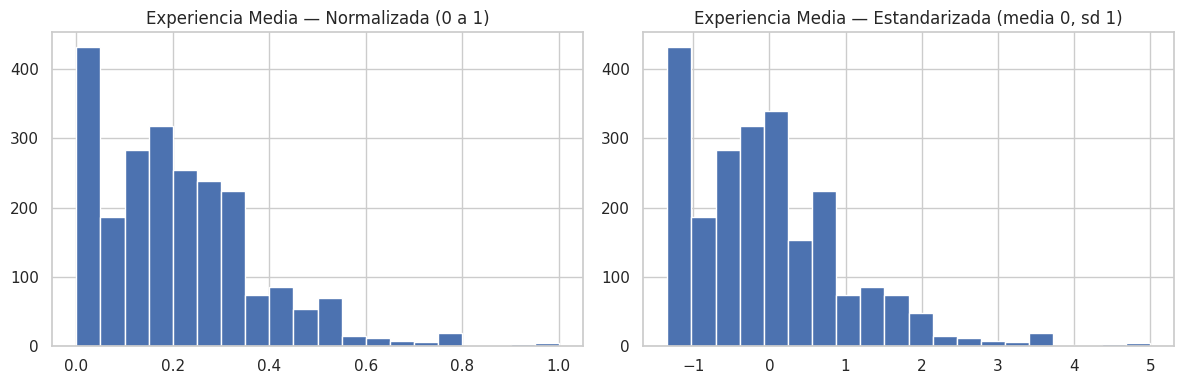

In [498]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(norm["Experiencia Media (minmax)"], bins=20, edgecolor="white")
axes[0].set_title("Experiencia Media — Normalizada (0 a 1)")
axes[1].hist(std["Experiencia Media (zscore)"], bins=20, edgecolor="white")
axes[1].set_title("Experiencia Media — Estandarizada (media 0, sd 1)")
plt.tight_layout()
plt.show()

**Interpretación:**
- Con **Min-Max**, `Experiencia Media` queda entre 0 y 1 con media ≈ 0,21 (los valores se concentran en la parte baja porque la distribución está sesgada).
- Con **Z-score**, la media es 0 y la desviación estándar 1; el valor máximo llega a ≈ 5 desviaciones estándar, lo que vuelve a señalar los outliers senior.
- El escalado **no cambia la forma** de la distribución (sigue sesgada), solo la escala. Para usar estas variables en modelos que asumen normalidad habría que aplicar además una transformación (por ejemplo logaritmo).
- **Cuándo usar cada uno:** Min-Max para KNN, K-Means o redes neuronales; Z-score para regresión lineal/logística o SVM y cuando hay outliers.

---


## 9. Conclusiones, hipótesis y aplicación profesional

### Hallazgos principales
1. El mercado pide en promedio **3–7 años** de experiencia; la mediana de la experiencia media es **4,5 años**. Predominan los perfiles junior y mid.
2. Todas las variables de experiencia tienen **asimetría positiva**: pocas ofertas muy senior estiran la media. La mediana describe mejor "la oferta típica".
3. Una sola consultora (**TandA HR Solutions**) publica el **15 %** de las ofertas y el mercado se concentra geográficamente en **India** (Bengaluru a la cabeza).
4. Las ofertas **para el exterior (15 %)** exigen más experiencia (media 6,1 vs. 5,0 años) y son más homogéneas.
5. `Min` y `Max Experience` están correlacionadas **0,93** → el dataset es coherente.
6. Cerca del **2 %** de las ofertas son outliers de experiencia: puestos de dirección reales (20–25 años), que se conservan.

### Hipótesis planteadas
- **H1:** las ofertas internacionales requieren más experiencia que las locales. *Los datos la respaldan* (media 6,1 vs. 5,0; mediana 5,5 vs. 4,5).
- **H2:** la mayoría de las vacantes IT del dataset son de nivel junior/mid (≤ 7 años). *Se cumple:* el 75 % de las ofertas está en 7 años o menos de experiencia media.
- **H3:** la experiencia requerida no se distribuye de forma normal, sino sesgada a la derecha. *Confirmada* por la asimetría y los histogramas.

### Aplicación en Ingeniería de Sistemas
- Sirve para **orientar el plan de carrera**: saber qué roles y qué nivel de experiencia demanda el mercado, y en qué punto (junior/mid/senior) hay más oportunidades.
- El proceso completo (definir variables derivadas, medir centro y dispersión, detectar outliers, escalar) es el mismo **preprocesamiento** que se aplica antes de construir cualquier modelo de datos en un proyecto real de software/analítica.

---

In [499]:
df.to_csv("IT_jobs_modulo2.csv", index=False)
print("Guardado IT_jobs_modulo2.csv con", df.shape[0], "filas y", df.shape[1], "columnas")
df.head()

Guardado IT_jobs_modulo2.csv con 2283 filas y 10 columnas


,Job Title,Company Name,Location,Experience (Years),Min Experience,Max Experience,Experiencia Media,Rango Experiencia,Num Ubicaciones,Oferta Exterior
0,Abroad Requirement IT Manager,RECRUITMENT CANADA IMMIGRATION CANADA,"Australia, Canada",7 - 12 Years,7,12,9.50,5,2,True
1,"""IT Sales Executive"" , Business Development Ex...",Serviots technology Pvt Ltd,Ahmedabad,2 - 6 Years,2,6,4.00,4,1,False
2,Facilities Manager,Sameer namdep Kedari,"Bengaluru / Bangalore, Sibsagar, Bhagalpur, Mu...",4 - 9 Years,4,9,6.50,5,5,False
3,SAP Experienced Candidates,TORRENT POWER LIMITED,Ahmedabad,3 - 5 Years,3,5,4.00,2,1,False
4,Technician- Electrical Maintenance,Suman kumar,"Delhi, Gurgaon, Pune, Indore, Bhubaneshwar",5 - 10 Years,5,10,7.50,5,5,False


## Módulo 3: Modelado Matemático, Visualización y Storytelling

**Programa:** Ingeniería de Sistemas

**Fecha:** septiembre de 2026

**Punto de partida:** `IT_jobs_modulo2.csv` (dataset del Módulo 2 — 2.283 filas, 10 columnas).

---

## Objetivo del Módulo 3

Cerrar el proyecto convirtiendo el análisis en **decisiones y comunicación**:

1. **Visualizar** los hallazgos con el tipo de gráfico correcto para cada mensaje
   (barras, histograma, boxplot, violín, dispersión).
2. Construir un **modelo predictivo simple** (regresión lineal) que estime cuántos
   años de experiencia pide una oferta, **entrenarlo y evaluarlo** con métricas
   (R², MAE, MSE/RMSE) y **validación cruzada**.
3. Probar además una **regresión logística** (clasificación) y leer su desempeño con
   la **matriz de confusión** y las métricas de clasificación (precisión, recall,
   F1, AUC).
4. Ordenar todo en una **narrativa de datos** (inicio – desarrollo – cierre) y
   proponer una **aplicación profesional** para Ingeniería de Sistemas.

---

In [500]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [501]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

In [502]:
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [503]:
df = pd.read_csv("IT_jobs_modulo2.csv")

In [504]:
print(df.shape)

(2283, 10)


In [505]:
print(df.columns.tolist())
df.head()

['Job Title', 'Company Name', 'Location', 'Experience (Years)', 'Min Experience', 'Max Experience', 'Experiencia Media', 'Rango Experiencia', 'Num Ubicaciones', 'Oferta Exterior']


,Job Title,Company Name,Location,Experience (Years),Min Experience,Max Experience,Experiencia Media,Rango Experiencia,Num Ubicaciones,Oferta Exterior
0,Abroad Requirement IT Manager,RECRUITMENT CANADA IMMIGRATION CANADA,"Australia, Canada",7 - 12 Years,7,12,9.500,5,2,True
1,"""IT Sales Executive"" , Business Development Ex...",Serviots technology Pvt Ltd,Ahmedabad,2 - 6 Years,2,6,4.000,4,1,False
2,Facilities Manager,Sameer namdep Kedari,"Bengaluru / Bangalore, Sibsagar, Bhagalpur, Mu...",4 - 9 Years,4,9,6.500,5,5,False
3,SAP Experienced Candidates,TORRENT POWER LIMITED,Ahmedabad,3 - 5 Years,3,5,4.000,2,1,False
4,Technician- Electrical Maintenance,Suman kumar,"Delhi, Gurgaon, Pune, Indore, Bhubaneshwar",5 - 10 Years,5,10,7.500,5,5,False


## 1. Punto de partida: la salida del Módulo 2

En lugar de volver a calcular las variables derivadas, partimos directamente de
`IT_jobs_modulo2.csv`, el archivo que exportamos al final del Módulo 2. Ya incluye:

- `Experiencia Media` = (Min + Max) / 2
- `Rango Experiencia` = Max − Min
- `Num Ubicaciones` = nº de ciudades/países que lista la oferta
- `Oferta Exterior` = `True` si la oferta es fuera de India

Lo único que añadimos en el Módulo 3 es una variable nueva: el **nivel del título**
(`Nivel Titulo`).

---

In [506]:
df.info()
print("\nOfertas al exterior:", int(df["Oferta Exterior"].sum()),
      f'({df["Oferta Exterior"].mean()*100:.1f}%)')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2283 entries, 0 to 2282
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job Title           2283 non-null   object 
 1   Company Name        2283 non-null   object 
 2   Location            2283 non-null   object 
 3   Experience (Years)  2283 non-null   object 
 4   Min Experience      2283 non-null   int64  
 5   Max Experience      2283 non-null   int64  
 6   Experiencia Media   2283 non-null   float64
 7   Rango Experiencia   2283 non-null   int64  
 8   Num Ubicaciones     2283 non-null   int64  
 9   Oferta Exterior     2283 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(4)
memory usage: 162.9+ KB

Ofertas al exterior: 350 (15.3%)


## 2. Variable nueva del Módulo 3: `Nivel Titulo` (ingeniería de características)

El **feature engineering** ("ingeniería de características") consiste en crear
variables nuevas y más útiles a partir de las que ya tenemos. Aquí leemos el texto
del **título del puesto** y lo clasificamos en tres niveles de seniority:

- **`senior`** si el título contiene palabras como *senior, lead, head, manager,
  director, chief, architect, principal, VP*…
- **`junior`** si contiene *junior, intern, trainee, graduate, fresher, entry,
  associate, apprentice*…
- **`medio`** en cualquier otro caso.

Esta variable nos servirá como predictora en el modelo: convierte información de
**texto** (que un modelo no entiende) en una **categoría** que sí puede usar.

---

In [507]:
t = df["Job Title"].str.lower()

In [508]:
senior_kw = (r"senior|sr\.?|lead|principal|head|director|chief|\bvp\b|president|"
             r"manager|mgr|gm\b|architect|expert")

In [509]:
junior_kw = r"junior|jr\.?|intern|trainee|graduate|fresher|entry|associate|apprentice"

In [510]:
df["Nivel Titulo"] = np.select(
    [t.str.contains(senior_kw, regex=True, na=False),
     t.str.contains(junior_kw, regex=True, na=False)],
    ["senior", "junior"],
    default="medio"
)

In [511]:
print(df["Nivel Titulo"].value_counts())

Nivel Titulo
medio     1453
senior     683
junior     147
Name: count, dtype: int64


In [512]:
print((df["Nivel Titulo"].value_counts(normalize=True) * 100).round(1))

Nivel Titulo
medio    63.600
senior   29.900
junior    6.400
Name: proportion, dtype: float64


In [513]:
resumen_nivel = df.groupby("Nivel Titulo")["Experiencia Media"].agg(
    ["count", "mean", "median", "std"]
).round(2).loc[["junior", "medio", "senior"]]
resumen_nivel

,count,mean,median,std
Nivel Titulo,,,,
junior,147,1.390,0.500,1.920
medio,1453,4.480,4.000,2.580
senior,683,7.400,6.500,4.040


**Interpretación:** la variable que acabamos de inventar tiene sentido: la experiencia
media pedida **sube de forma clara con el nivel del título**.

| Nivel | Nº ofertas | Experiencia media (media) | Mediana |
|---|---|---|---|
| `junior` | 147 | **1,4 años** | 0,5 |
| `medio` | 1.453 | **4,5 años** | 4,0 |
| `senior` | 683 | **7,4 años** | 6,5 |

Que una variable derivada del **texto del título** separe tan bien la experiencia es
una buena señal de que servirá como predictora en el modelo.

---

## 3. Visualizaciones para contar la historia

Cada gráfico responde a una pregunta distinta y por eso se elige un tipo distinto:

| Gráfico | Para qué sirve | Qué mostramos |
|---|---|---|
| **Barras** | comparar categorías independientes | los 10 puestos más frecuentes |
| **Histograma** | ver la forma de la distribución de una variable numérica | experiencia media pedida |
| **Boxplot** (caja y bigotes) | comparar la distribución entre grupos y ver outliers | experiencia por nivel del título |
| **Violín** | como el boxplot pero además muestra la densidad (dónde se acumulan los datos) | experiencia: local vs. exterior |
| **Dispersión** | ver la relación entre dos variables numéricas | experiencia mínima vs. máxima |

---

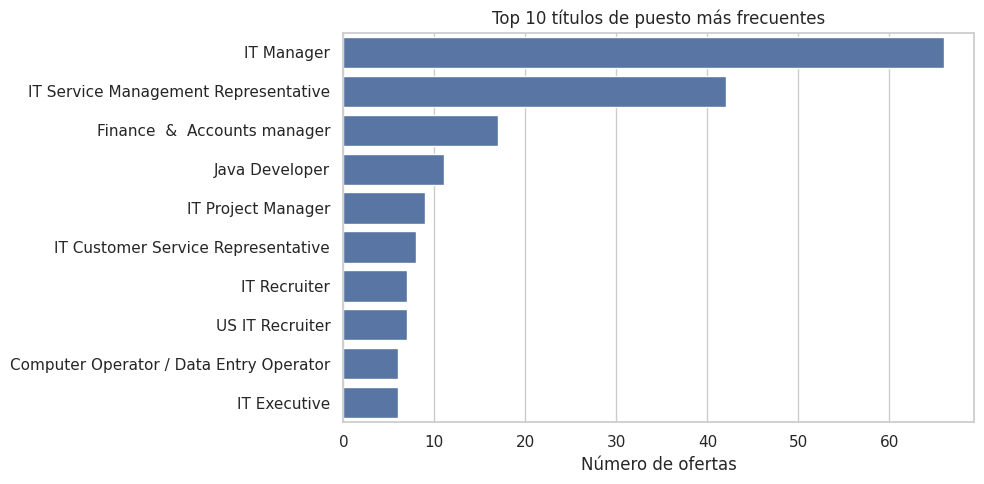

In [514]:
top_jobs = df["Job Title"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_jobs.values, y=top_jobs.index, color="#4C72B0")
plt.title("Top 10 títulos de puesto más frecuentes")
plt.xlabel("Número de ofertas")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Gráfico de barras — lectura:** el mercado está muy fragmentado. *IT Manager* (66) e
*IT Service Management Representative* (42) encabezan, y a partir del tercer puesto
(*Finance & Accounts manager*, 17) la frecuencia se desploma. No hay un rol dominante:
hay muchísimos títulos distintos con pocas ofertas cada uno (**1.897 títulos únicos**
en 2.283 ofertas).

---

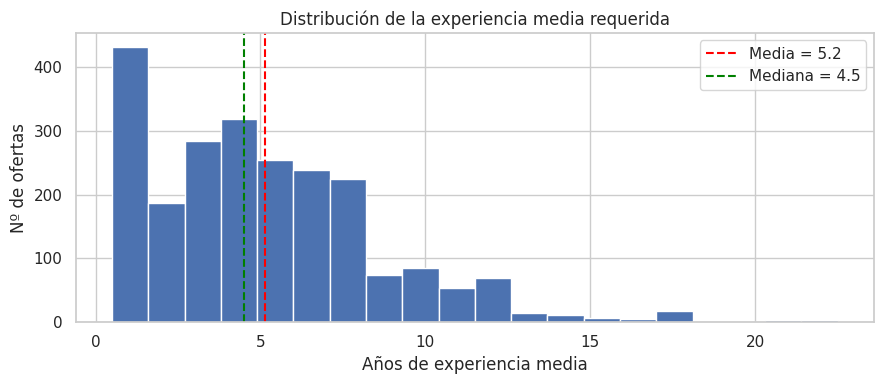

In [515]:
media = df["Experiencia Media"].mean()
mediana = df["Experiencia Media"].median()

plt.figure(figsize=(9, 4))
plt.hist(df["Experiencia Media"], bins=20, edgecolor="white", color="#4C72B0")
plt.axvline(media,   color="red",   linestyle="--", label=f"Media = {media:.1f}")
plt.axvline(mediana, color="green", linestyle="--", label=f"Mediana = {mediana:.1f}")
plt.title("Distribución de la experiencia media requerida")
plt.xlabel("Años de experiencia media")
plt.ylabel("Nº de ofertas")
plt.legend()
plt.tight_layout()
plt.show()

**Histograma — lectura:** la distribución está **sesgada a la derecha** (asimetría
positiva). La mayoría de las ofertas se concentran entre **0 y 7 años**, con un pico
en los valores bajos, y una **cola larga** de ofertas muy senior (15–25 años) que
tira de la media hacia arriba. Por eso la **media (5,2)** es mayor que la
**mediana (4,5)**: cuando hay cola a la derecha, la mediana describe mejor "la oferta
típica".

---

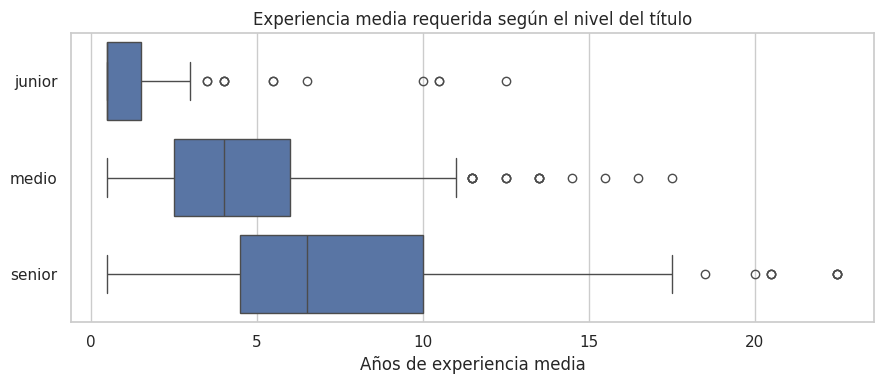

In [516]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x="Experiencia Media", y="Nivel Titulo",
            order=["junior", "medio", "senior"], color="#4C72B0")
plt.title("Experiencia media requerida según el nivel del título")
plt.xlabel("Años de experiencia media")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Boxplot — lectura:** las tres cajas están **claramente separadas**. Las ofertas
`junior` piden mediana 0,5 años (caja pegada a 0); las `medio`, unos 4; las `senior`,
6,5 con una caja mucho más ancha y una cola larga de outliers (hasta 20–25 años:
puestos de dirección). El nivel del título **sí ordena** la experiencia pedida →
buena pista de que funcionará como predictor.

---


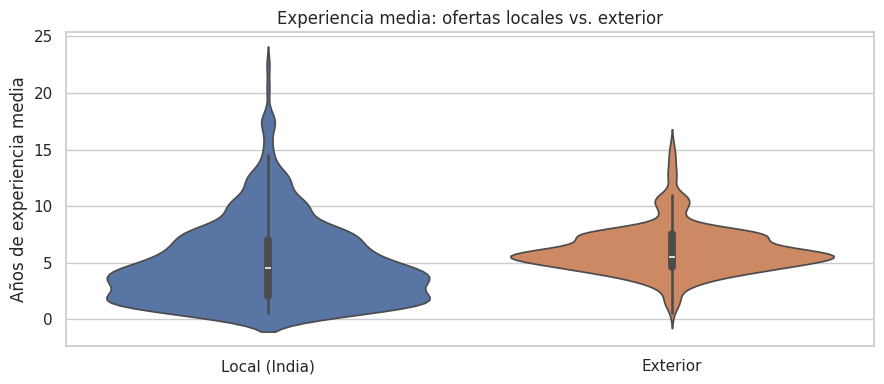

In [517]:
plt.figure(figsize=(9, 4))
sns.violinplot(data=df, x="Oferta Exterior", y="Experiencia Media",
               hue="Oferta Exterior", palette=["#4C72B0", "#DD8452"], legend=False)
plt.xticks([0, 1], ["Local (India)", "Exterior"])
plt.title("Experiencia media: ofertas locales vs. exterior")
plt.xlabel("")
plt.ylabel("Años de experiencia media")
plt.tight_layout()
plt.show()

**Violín — lectura:** el violín es un boxplot + la "silueta" de la densidad (dónde se
acumulan los datos). Las locales tienen la parte ancha **abajo** (muchas ofertas
junior/mid, forma alargada: mucha variedad, desv. estándar 3,6). Las del exterior
tienen la masa **más arriba y más compacta** (media 6,1 vs. 5,0 años; desv. estándar
2,1): fuera de India se pide **más experiencia y más homogénea**. Para aspirar a una
oferta internacional conviene apuntar a un perfil de 5–8 años.

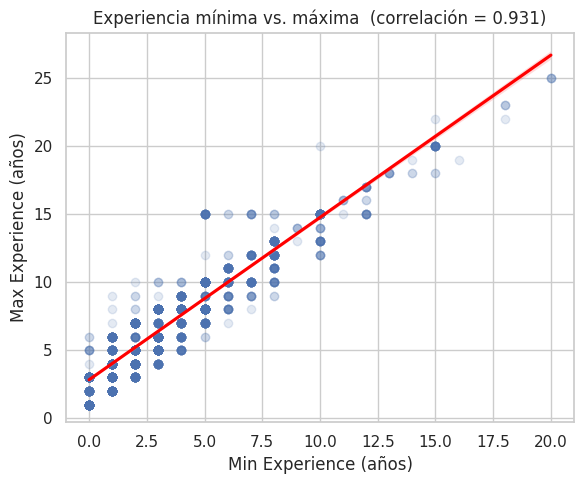

In [518]:
corr = df["Min Experience"].corr(df["Max Experience"])

plt.figure(figsize=(6, 5))
sns.regplot(data=df, x="Min Experience", y="Max Experience",
            scatter_kws={"alpha": 0.15}, line_kws={"color": "red"})
plt.title(f"Experiencia mínima vs. máxima  (correlación = {corr:.3f})")
plt.xlabel("Min Experience (años)")
plt.ylabel("Max Experience (años)")
plt.tight_layout()
plt.show()



**Dispersión — lectura:** la nube sube de izquierda a derecha de forma casi recta.
La **correlación es 0,931**: relación positiva muy fuerte. Cuanta más experiencia
mínima pide una oferta, más alto es también su tope. Esa recta roja es, literalmente,
el modelo de la siguiente sección: una **regresión lineal** de `Max Experience` sobre
`Min Experience`.

## 4. Modelo predictivo: regresión lineal

La **regresión lineal** busca la recta que mejor predice una variable numérica
(**dependiente**, `y`) a partir de otras (**independientes**, `X`):

> `y = b0 + b1·x1 + b2·x2 + ... + error`

- `b0` (**intercepto**): valor de `y` cuando todas las `x` valen 0.
- `b1, b2…` (**coeficientes / pendientes**): cuánto cambia `y` por cada unidad que
  sube esa `x`, manteniendo las demás fijas.

**Qué vamos a predecir:** `Max Experience` — el **tope de experiencia** que pide una
oferta. Es un valor numérico continuo → regresión (no clasificación).

**Cómo lo evaluamos:**
- Partimos los datos en **entrenamiento (80 %)** y **prueba (20 %)**. El modelo
  aprende solo con el 80 % y lo medimos con el 20 % que **nunca vio**.
- Métricas: **R²** (proporción de la variación explicada, 0 a 1; más alto mejor),
  **MAE** (error absoluto medio, en años; más bajo mejor), **MSE / RMSE** (error
  cuadrático; penaliza más los errores grandes; RMSE vuelve a estar en años).

---


### 4.1 Regresión lineal simple: `Max Experience` ~ `Min Experience`

Empezamos con **una sola** variable predictora, para ver el concepto en su forma más
pura (es la recta roja del gráfico de dispersión anterior).

---

In [519]:
X = df[["Min Experience"]]      # predictora (mayúscula: es una matriz)
y = df["Max Experience"]        # objetivo   (minúscula: es un vector)

In [520]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

In [521]:
modelo_simple = LinearRegression().fit(X_train, y_train)

In [522]:

print(f"Intercepto (b0): {modelo_simple.intercept_:.3f}")
print(f"Coeficiente Min Experience (b1): {modelo_simple.coef_[0]:.3f}")
print(f"\nEcuación:  Max Experience ≈ {modelo_simple.intercept_:.2f} "
      f"+ {modelo_simple.coef_[0]:.2f} · Min Experience")

Intercepto (b0): 2.822
Coeficiente Min Experience (b1): 1.193

Ecuación:  Max Experience ≈ 2.82 + 1.19 · Min Experience


In [523]:
pred_simple = modelo_simple.predict(X_test)

r2   = r2_score(y_test, pred_simple)
mae  = mean_absolute_error(y_test, pred_simple)
mse  = mean_squared_error(y_test, pred_simple)
rmse = mse ** 0.5

print(f"R²   = {r2:.3f}")
print(f"MAE  = {mae:.3f} años")
print(f"MSE  = {mse:.3f}")
print(f"RMSE = {rmse:.3f} años")

R²   = 0.868
MAE  = 1.158 años
MSE  = 2.095
RMSE = 1.447 años


In [524]:
# Comparación con un modelo de referencia (predecir siempre la media)
mae_base = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean(), dtype=float))
print(f"\nMAE del modelo de referencia (siempre la media) = {mae_base:.3f} años")


MAE del modelo de referencia (siempre la media) = 3.059 años


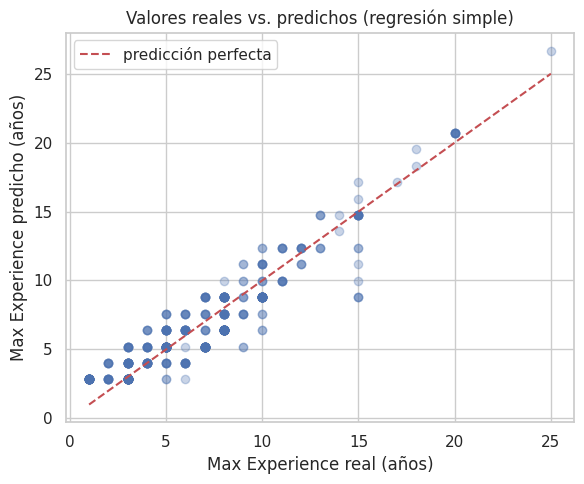

In [525]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_simple, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         "r--", label="predicción perfecta")
plt.title("Valores reales vs. predichos (regresión simple)")
plt.xlabel("Max Experience real (años)")
plt.ylabel("Max Experience predicho (años)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación — regresión lineal simple:**

- **Ecuación del modelo:** `Max Experience ≈ 2,82 + 1,19 · Min Experience`. El
  coeficiente indica que, por cada año adicional de experiencia mínima que solicita
  una oferta, su tope de experiencia se eleva alrededor de **1,2 años**; el intercepto
  señala que una oferta cuya experiencia mínima es 0 pide, en promedio, un tope
  cercano a **2,8 años**.
- **Coeficiente de determinación (R²) = 0,868:** la experiencia mínima explica por sí
  sola cerca del **87 % de la variación** del tope de experiencia. Es un valor
  elevado para un modelo de una sola variable, coherente con el hecho de que ambas
  magnitudes describen los dos extremos de un mismo rango.
- **Error absoluto medio (MAE) = 1,16 años:** en promedio, la predicción se desvía
  poco más de un año respecto del valor real. Para dimensionar ese resultado lo
  comparamos con un **modelo de referencia** que se limitara a predecir siempre la
  media (MAE de 3,06 años): nuestro modelo reduce el error a aproximadamente un
  tercio.
- El **gráfico de valores reales frente a predichos** muestra los puntos alineados a
  lo largo de la diagonal, con una dispersión algo mayor en los valores altos, que
  corresponden a las ofertas más senior y son, por su escasez, más difíciles de
  ajustar.

### 4.2 Regresión lineal múltiple: añadir el contexto de la oferta

Ahora usamos **varias** predictoras a la vez. ¿Mejora la predicción del tope si además
de la experiencia mínima le damos al modelo el contexto de la oferta?

- `Min Experience` (numérica)
- `exterior` = 1 si es oferta internacional, 0 si es local
- `num_ubic` = número de ubicaciones
- `nivel_medio`, `nivel_senior` = el nivel del título convertido en columnas 0/1
  (**variables dummy**). Dejamos `junior` como **categoría de referencia**: los
  coeficientes de `nivel_medio` y `nivel_senior` se leen *frente a una oferta junior*.

---

In [526]:
df["exterior"]     = df["Oferta Exterior"].astype(int)
df["num_ubic"]     = df["Num Ubicaciones"]
df["nivel_medio"]  = (df["Nivel Titulo"] == "medio").astype(int)
df["nivel_senior"] = (df["Nivel Titulo"] == "senior").astype(int)
# 'junior' es la categoría base: nivel_medio = nivel_senior = 0

In [527]:
features = ["Min Experience", "exterior", "num_ubic", "nivel_medio", "nivel_senior"]
X = df[features]
y = df["Max Experience"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

modelo_mult = LinearRegression().fit(X_train, y_train)

In [528]:
coefs = pd.DataFrame({
    "variable": features,
    "coeficiente": modelo_mult.coef_
}).sort_values("coeficiente", ascending=False)
print(coefs.to_string(index=False))
print(f"\nIntercepto: {modelo_mult.intercept_:.3f}")

      variable  coeficiente
  nivel_senior        1.474
   nivel_medio        1.211
      exterior        1.171
Min Experience        1.147
      num_ubic        0.212

Intercepto: 1.185


In [529]:
pred_mult = modelo_mult.predict(X_test)

print("REGRESIÓN MÚLTIPLE (conjunto de prueba)")
print(f"R²   = {r2_score(y_test, pred_mult):.3f}")
print(f"MAE  = {mean_absolute_error(y_test, pred_mult):.3f} años")
print(f"RMSE = {mean_squared_error(y_test, pred_mult) ** 0.5:.3f} años")

print("\nComparación con la regresión simple:")
print(f"  R²   simple = {r2:.3f}   →   múltiple = {r2_score(y_test, pred_mult):.3f}")
print(f"  MAE  simple = {mae:.3f}   →   múltiple = {mean_absolute_error(y_test, pred_mult):.3f}")

REGRESIÓN MÚLTIPLE (conjunto de prueba)
R²   = 0.893
MAE  = 0.975 años
RMSE = 1.303 años

Comparación con la regresión simple:
  R²   simple = 0.868   →   múltiple = 0.893
  MAE  simple = 1.158   →   múltiple = 0.975


**Interpretación — regresión múltiple:**

| Variable | Coeficiente | Lectura (efecto sobre el tope de experiencia) |
|---|---|---|
| `Min Experience` | **+1,15** | cada año de experiencia mínima sube el tope ~1,2 años |
| `nivel_senior` | **+1,47** | un título senior pide ~1,5 años más de tope que uno junior… |
| `nivel_medio` | **+1,21** | …y uno de nivel medio, ~1,2 años más que uno junior |
| `exterior` | **+1,17** | una oferta internacional pide ~1,2 años más de tope |
| `num_ubic` | **+0,21** | cada ubicación adicional suma ~0,2 años (efecto pequeño) |
| intercepto | +1,19 | punto de partida (oferta junior, local, 1 ubicación, mínimo 0) |

- **R² sube de 0,868 a 0,893** y el **MAE baja de 1,16 a 0,98 años**: añadir el
  contexto (nivel, país, ubicaciones) **mejora** la predicción, aunque poco, porque
  `Min Experience` ya cargaba casi toda la información.
- Todos los coeficientes son **positivos y con sentido de negocio**: seniority en el
  título, oferta internacional y más ubicaciones → más experiencia exigida.

---

### 4.3 Validación cruzada (k-fold)

Una sola partición 80/20 puede salir "con suerte". La **validación cruzada** parte los
datos en **k = 5 trozos (folds)**: entrena 5 veces, cada vez con 4 trozos y evaluando
en el que quedó fuera, y promedia los 5 resultados. Da una estimación **más estable**
del rendimiento real y detecta **sobreajuste** (si el modelo va mucho mejor en
entrenamiento que en prueba).

---

In [530]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_simple = cross_val_score(LinearRegression(), df[["Min Experience"]],
                            df["Max Experience"], cv=kf, scoring="r2")
cv_mult   = cross_val_score(LinearRegression(), df[features],
                            df["Max Experience"], cv=kf, scoring="r2")

print("R² por fold (simple): ", np.round(cv_simple, 3))
print(f"  media = {cv_simple.mean():.3f}  ±  {cv_simple.std():.3f}")
print("R² por fold (múltiple):", np.round(cv_mult, 3))
print(f"  media = {cv_mult.mean():.3f}  ±  {cv_mult.std():.3f}")

print(f"\nR² en entrenamiento (múltiple): {modelo_mult.score(X_train, y_train):.3f}")
print(f"R² en prueba        (múltiple): {modelo_mult.score(X_test,  y_test):.3f}")

R² por fold (simple):  [0.868 0.877 0.866 0.861 0.856]
  media = 0.865  ±  0.007
R² por fold (múltiple): [0.893 0.894 0.891 0.888 0.875]
  media = 0.888  ±  0.007

R² en entrenamiento (múltiple): 0.888
R² en prueba        (múltiple): 0.893



**Interpretación — validación cruzada:**
- **Simple:** R² medio **0,865** (folds entre 0,856 y 0,877; desviación 0,007).
- **Múltiple:** R² medio **0,888** (folds entre 0,875 y 0,894; desviación 0,007).
- Los 5 folds dan casi lo mismo → el resultado **no dependía de la partición**, es
  sólido.
- R² en entrenamiento (0,888) ≈ R² en prueba (0,893) → **no hay sobreajuste**: el
  modelo generaliza bien a datos nuevos. La regresión lineal es un modelo simple y
  aquí eso es una ventaja.

---

## 5. Un segundo enfoque: clasificación con regresión logística

Además del modelo de regresión, exploramos una pregunta de naturaleza distinta:
**¿es posible anticipar si una oferta está dirigida al mercado internacional?** Como
la respuesta solo admite dos valores (`sí` / `no`), el modelo adecuado no es una
regresión lineal sino una **regresión logística**, que estima la **probabilidad**
—entre 0 y 1— de que una oferta pertenezca a esa categoría.

- **Variables predictoras:** `Experiencia Media`, `Num Ubicaciones`, `nivel_medio` y
  `nivel_senior`.
- Solo el **15,3 %** de las ofertas son internacionales, de modo que las **clases
  están desbalanceadas**. Empleamos `class_weight="balanced"` para que el modelo no
  ignore a la clase minoritaria.
- Utilizamos una **partición estratificada** (`stratify=y`), que conserva esa
  proporción del 15,3 % tanto en el conjunto de entrenamiento como en el de prueba.

---

In [531]:
feat_log = ["Experiencia Media", "Num Ubicaciones", "nivel_medio", "nivel_senior"]
X = df[feat_log]
y = df["exterior"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train, y_train)

pred_log  = clf.predict(X_test)
proba_log = clf.predict_proba(X_test)[:, 1]   # probabilidad de "exterior"

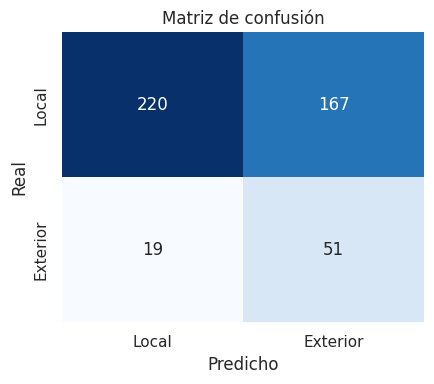

Accuracy  = 0.593
Precisión = 0.234
Recall    = 0.729
F1        = 0.354
AUC-ROC   = 0.661


In [532]:
cm = confusion_matrix(y_test, pred_log)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Local", "Exterior"], yticklabels=["Local", "Exterior"])
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print(f"Accuracy  = {accuracy_score(y_test, pred_log):.3f}")
print(f"Precisión = {precision_score(y_test, pred_log):.3f}")
print(f"Recall    = {recall_score(y_test, pred_log):.3f}")
print(f"F1        = {f1_score(y_test, pred_log):.3f}")
print(f"AUC-ROC   = {roc_auc_score(y_test, proba_log):.3f}")

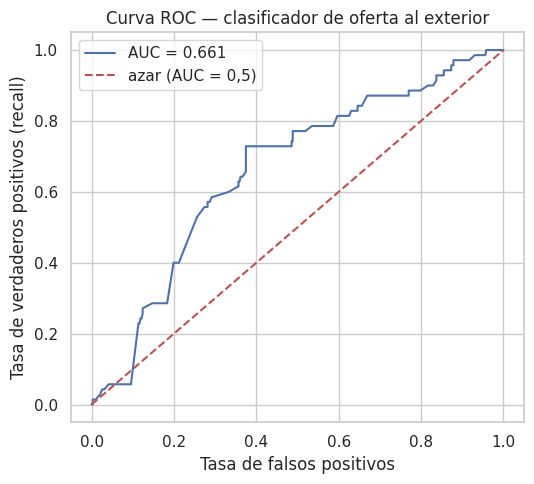

In [533]:
fpr, tpr, _ = roc_curve(y_test, proba_log)

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba_log):.3f}")
plt.plot([0, 1], [0, 1], "r--", label="azar (AUC = 0,5)")
plt.title("Curva ROC — clasificador de oferta al exterior")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación — regresión logística:**

La matriz de confusión resume el desempeño sobre las 457 ofertas del conjunto de
prueba, de las cuales 70 eran realmente internacionales:

|  | Predijo Local | Predijo Exterior |
|---|---|---|
| **Real Local** | 220 (verdaderos negativos) | 167 (falsos positivos) |
| **Real Exterior** | 19 (falsos negativos) | 51 (verdaderos positivos) |

- La **exactitud (accuracy)** es de 0,59, y este dato ilustra un principio importante
  del análisis de clasificación: como solo el 15,3 % de las ofertas son
  internacionales, un modelo que se limitara a responder *"ninguna lo es"* alcanzaría
  un 84,7 % de aciertos sin aportar ningún valor. Ante **clases desbalanceadas**, la
  exactitud por sí sola no es una medida fiable.
- La **exhaustividad (recall)** es de 0,73: el modelo identifica 51 de las 70 ofertas
  internacionales, un comportamiento adecuado si el objetivo fuera no dejar pasar
  oportunidades de ese tipo.
- La **precisión** es de 0,23: de cada cien ofertas que el modelo señala como
  internacionales, solo veintitrés lo son en realidad. Se aprecia con claridad el
  **equilibrio entre precisión y exhaustividad**: ganar en una suele implicar ceder
  en la otra.
- El **área bajo la curva ROC (AUC)** es de 0,66, un valor solo ligeramente superior
  al del azar (0,5). La capacidad de discriminación del modelo es, por tanto,
  **limitada**. Este resultado es en sí mismo un hallazgo: con las variables
  disponibles —experiencia, número de ubicaciones y nivel del título— no se puede
  determinar de forma fiable la orientación geográfica de una oferta, que
  probablemente dependa de factores no recogidos en el conjunto de datos, como el
  sector de la empresa, el idioma del anuncio o las condiciones salariales.
  Identificar los límites de un modelo forma parte del trabajo de análisis.

---

## 6. Narrativa de datos: contar la historia detrás del análisis

El último paso de un proyecto de ciencia de datos no consiste únicamente en obtener un
resultado, sino en **comunicarlo de forma que quien lo recibe lo entienda, lo recuerde
y pueda actuar en consecuencia**. Una narrativa de datos bien construida sigue la
misma estructura que cualquier buen relato: un planteamiento que aporta contexto, un
desarrollo que presenta la evidencia de manera progresiva y un cierre que traduce los
hallazgos en conclusiones y decisiones. Organizamos aquí el proyecto completo según
esa estructura.

### Planteamiento — la pregunta que nos hicimos

Como estudiantes de Ingeniería de Sistemas, el mercado laboral de tecnología es
nuestro propio campo profesional. Quisimos responder, apoyándonos en datos reales y no
en impresiones, a tres preguntas concretas: **qué perfiles demanda el sector, cuánta
experiencia exige y dónde se concentran las oportunidades**. Para ello partimos de
2.500 ofertas de empleo recopiladas en Kaggle que, tras el proceso de depuración del
Módulo 1, quedaron reducidas a 2.283 registros consistentes y listos para el análisis.

### Desarrollo — lo que revelaron los datos

Cada visualización se escogió para responder a una parte de la pregunta:

- El **gráfico de barras** de los puestos más frecuentes describió un mercado muy
  fragmentado: 1.897 títulos distintos en 2.283 ofertas, sin ningún rol que
  predomine. La demanda de TI es amplia y diversa, no está concentrada en unos pocos
  cargos.
- El **histograma** de la experiencia requerida mostró una distribución claramente
  asimétrica hacia la derecha: la mayor parte de las ofertas se dirige a perfiles de
  entrada e intermedios —la mediana se sitúa en 4,5 años—, acompañados de una cola de
  vacantes muy senior que eleva la media pero no representa al grueso del mercado.
- El **diagrama de caja por nivel del título** confirmó que la variable que
  construimos a partir del texto de cada puesto (`Nivel Titulo`) ordena de forma
  coherente la experiencia exigida: en torno a 1,4 años para los perfiles junior,
  4,5 para los intermedios y 7,4 para los senior.
- El **diagrama de violín** comparó las ofertas locales con las internacionales: el
  15,3 % de las publicaciones se dirige al exterior y exige, en promedio, más
  experiencia (6,1 frente a 5,0 años) y con menor dispersión, lo que apunta a un
  perfil más definido y homogéneo.
- El **diagrama de dispersión** entre experiencia mínima y máxima evidenció una
  relación lineal muy fuerte (correlación de 0,93), que sirvió de puente natural hacia
  el modelo predictivo.

Sobre esa relación construimos una **regresión lineal** capaz de estimar el tope de
experiencia que solicita una oferta con un coeficiente de determinación de 0,89 y un
error medio inferior a un año, un resultado que la validación cruzada confirmó como
estable. Además, exploramos un modelo de **clasificación** para anticipar si una
oferta es internacional; su capacidad de discriminación resultó limitada (AUC de
0,66), lo que nos permitió practicar la lectura de la matriz de confusión y de
métricas como la precisión y la exhaustividad, y comprender que la orientación
geográfica de una vacante depende de factores que este conjunto de datos no recoge.

### Cierre — qué concluimos y qué haríamos con ello

El mercado de TI representado en estos datos es, ante todo, un mercado de perfiles
junior e intermedios y fuertemente concentrado en India. La experiencia que exige una
oferta es una magnitud altamente predecible a partir de sus propias características;
su orientación internacional, en cambio, no lo es con la información disponible. Para
quien planifica su carrera, la lectura resulta clara: existen numerosas puertas de
entrada que requieren poca experiencia, mientras que el salto a posiciones
internacionales conviene prepararlo apuntando a un rango de 5 a 8 años de trayectoria.

---

## 7. Aplicación profesional

El valor de este trabajo no se agota en el análisis: las mismas herramientas y el
mismo razonamiento se trasladan de forma directa al ejercicio profesional de la
Ingeniería de Sistemas.

**Orientación de la trayectoria profesional.** El estudio ofrece una fotografía
objetiva de lo que el mercado solicita. Alrededor del 64 % de las ofertas corresponde
a perfiles de nivel intermedio que piden en torno a cuatro años de experiencia, de
manera que un profesional recién titulado puede situarse con realismo dentro de esa
escala y plantearse objetivos concretos —por ejemplo, alcanzar el rango de 5 a 8 años
que caracteriza a las vacantes internacionales— en lugar de guiarse por percepciones.

**Apoyo a los procesos de selección y a la planificación de personal.** Un modelo de
regresión que estima la experiencia razonable para una vacante a partir de sus
atributos resulta útil en un área de recursos humanos o en la dirección de un
proyecto: permite comprobar si una oferta está bien calibrada —detectar, por ejemplo,
que se exige un nivel de seniority incoherente con el resto de sus condiciones— y
aplicar un criterio uniforme al comparar candidaturas.

**Transferencia del método.** La secuencia recorrida a lo largo de las tres etapas
—depurar los datos, describirlos estadísticamente y, por último, modelar, visualizar y
comunicar— es precisamente el flujo de trabajo de cualquier proyecto de analítica o de
desarrollo de software orientado a datos. Haber completado ese ciclo sobre un caso
real constituye una competencia aplicable a la práctica profesional con independencia
del dominio concreto.

**Evolución natural del trabajo.** El siguiente paso lógico sería llevar estas
visualizaciones a un tablero de control interactivo —en Power BI o publicando este
mismo cuaderno con Voila— que incorpore filtros por rol, país y nivel de experiencia,
de modo que cualquier integrante del equipo pueda explorar la información y fundamentar
decisiones en la evidencia sin necesidad de manipular el código.

---

## 8. Conclusiones

### Sobre el Módulo 3

En esta etapa final trasladamos el análisis al terreno de la predicción y la
comunicación. Seleccionamos cinco tipos de gráfico —barras, histograma, diagrama de
caja, diagrama de violín y diagrama de dispersión— eligiendo en cada caso el más
adecuado para el mensaje que se quería transmitir, y acompañamos cada uno de su
lectura interpretativa.

Construimos y evaluamos un **modelo predictivo** de regresión lineal para estimar el
tope de experiencia que exige una oferta. En su versión simple, con la experiencia
mínima como única variable, explica el 87 % de la variabilidad; al incorporar el
contexto de la publicación —nivel del título, carácter internacional y número de
ubicaciones— asciende al 89 %, con un error medio de 0,98 años. La **validación
cruzada** en cinco particiones confirmó que ese rendimiento es estable y que el modelo
no presenta sobreajuste.

De forma complementaria, entrenamos un modelo de **regresión logística** para
clasificar las ofertas según su orientación geográfica. Su capacidad predictiva
resultó modesta (AUC de 0,66) y ese resultado, lejos de restar valor al trabajo, nos
permitió ejercitar la evaluación crítica de un clasificador: interpretar la matriz de
confusión, comprender por qué la exactitud puede ser engañosa ante clases
desbalanceadas y distinguir entre precisión y exhaustividad en función del tipo de
error que se quiera evitar. Reconocer los límites de un modelo también forma parte del
análisis.

### Sobre el proyecto en su conjunto

Las tres etapas encadenan el ciclo completo de un proyecto de ciencia de datos:

1. **Módulo 1 — Fundamentos y preparación.** Partimos de 2.500 registros y, tras
   tratar duplicados, valores nulos, texto inconsistente y variables mal tipificadas,
   obtuvimos un conjunto depurado de 2.283 filas y 6 columnas.
2. **Módulo 2 — Análisis estadístico.** Caracterizamos los datos mediante medidas de
   tendencia central, posición, dispersión y forma; detectamos valores atípicos,
   comparamos subgrupos y contrastamos hipótesis. La conclusión principal fue que la
   experiencia requerida sigue una distribución asimétrica, alejada de la normal.
3. **Módulo 3 — Modelado, visualización y narrativa.** Convertimos esa comprensión en
   un modelo capaz de predecir, en visualizaciones que la comunican y en una narrativa
   que la conecta con una aplicación profesional concreta.

El resultado es un análisis reproducible, documentado paso a paso y orientado a la
toma de decisiones, que integra los conceptos trabajados a lo largo de todo el curso.

---

In [534]:
df.to_csv("IT_jobs_modulo3.csv", index=False)
print("Guardado IT_jobs_modulo3.csv con", df.shape[0], "filas y", df.shape[1], "columnas")
df.head()

Guardado IT_jobs_modulo3.csv con 2283 filas y 15 columnas


,Job Title,Company Name,Location,Experience (Years),Min Experience,Max Experience,Experiencia Media,Rango Experiencia,Num Ubicaciones,Oferta Exterior,Nivel Titulo,exterior,num_ubic,nivel_medio,nivel_senior
0,Abroad Requirement IT Manager,RECRUITMENT CANADA IMMIGRATION CANADA,"Australia, Canada",7 - 12 Years,7,12,9.500,5,2,True,senior,1,2,0,1
1,"""IT Sales Executive"" , Business Development Ex...",Serviots technology Pvt Ltd,Ahmedabad,2 - 6 Years,2,6,4.000,4,1,False,medio,0,1,1,0
2,Facilities Manager,Sameer namdep Kedari,"Bengaluru / Bangalore, Sibsagar, Bhagalpur, Mu...",4 - 9 Years,4,9,6.500,5,5,False,senior,0,5,0,1
3,SAP Experienced Candidates,TORRENT POWER LIMITED,Ahmedabad,3 - 5 Years,3,5,4.000,2,1,False,medio,0,1,1,0
4,Technician- Electrical Maintenance,Suman kumar,"Delhi, Gurgaon, Pune, Indore, Bhubaneshwar",5 - 10 Years,5,10,7.500,5,5,False,medio,0,5,1,0
